# Part 0: NN Foundations

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, activation="relu"):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        if activation == "relu":
            self.act = nn.ReLU()
        elif activation == "sigmoid":
            self.act = nn.Sigmoid()
        else:
            raise ValueError("activation must be 'relu' or 'sigmoid'")
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

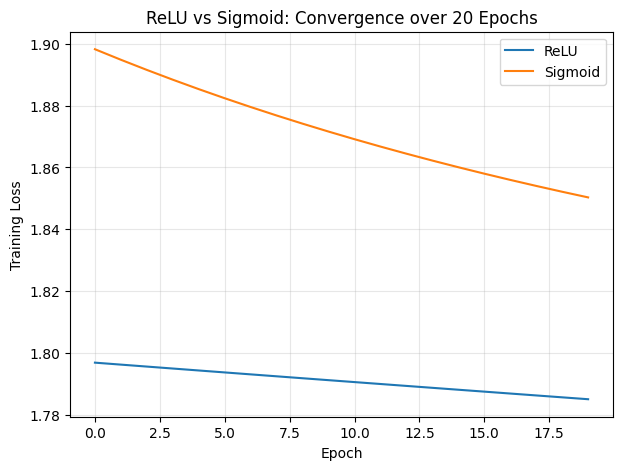

Final ReLU loss: 1.785077691078186
Final Sigmoid loss: 1.8503150939941406


In [4]:
def generate_synthetic_data(n_samples=600, n_features=100, n_classes=6):
    X = torch.randn(n_samples, n_features)
    # Create separable-ish classes via a fixed random linear projection
    W_true = torch.randn(n_features, n_classes)
    y = torch.argmax(X @ W_true + 0.5 * torch.randn(n_samples, n_classes), dim=1)
    return X, y

X_train, y_train = generate_synthetic_data()
X_train, y_train = X_train.to(device), y_train.to(device)

def train_simple(activation, epochs=20, lr=0.01):
    model = SimpleNN(input_size=100, hidden_size=32, num_classes=6,
                      activation=activation).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

relu_losses = train_simple("relu")
sigmoid_losses = train_simple("sigmoid")

plt.figure(figsize=(7, 5))
plt.plot(relu_losses, label="ReLU")
plt.plot(sigmoid_losses, label="Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("ReLU vs Sigmoid: Convergence over 20 Epochs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final ReLU loss:", relu_losses[-1])
print("Final Sigmoid loss:", sigmoid_losses[-1])

CrossEntropy final accuracy: 0.175
MSE final accuracy:          0.175


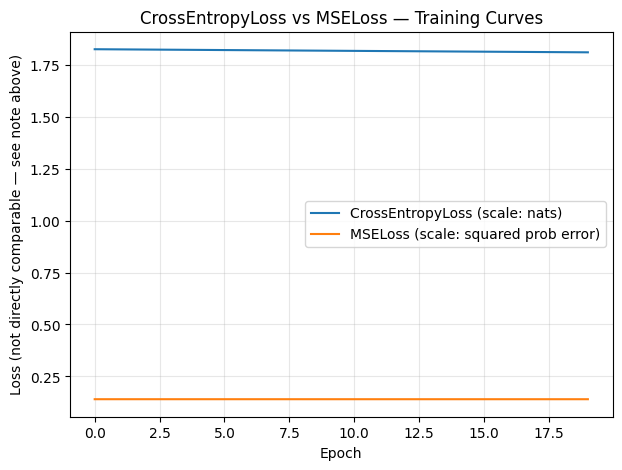

In [5]:


def train_with_loss(loss_type, epochs=20, lr=0.01):
    model = SimpleNN(input_size=100, hidden_size=32, num_classes=6,
                      activation="relu").to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)

    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)

        if loss_type == "ce":
            criterion = nn.CrossEntropyLoss()
            loss = criterion(outputs, y_train)
        elif loss_type == "mse":
            # MSE requires one-hot targets and probability-like outputs
            targets_onehot = nn.functional.one_hot(y_train, num_classes=6).float()
            probs = torch.softmax(outputs, dim=1)  # manual softmax since MSE has none built in
            criterion = nn.MSELoss()
            loss = criterion(probs, targets_onehot)

        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses, model

ce_losses, ce_model = train_with_loss("ce")
mse_losses, mse_model = train_with_loss("mse")

# Compare actual classification accuracy, not just raw loss values
# (the two losses are on different scales, so comparing loss numbers directly is meaningless)
def accuracy(model, X, y):
    with torch.no_grad():
        preds = torch.argmax(model(X), dim=1)
        return (preds == y).float().mean().item()

print(f"CrossEntropy final accuracy: {accuracy(ce_model, X_train, y_train):.3f}")
print(f"MSE final accuracy:          {accuracy(mse_model, X_train, y_train):.3f}")

plt.figure(figsize=(7, 5))
plt.plot(ce_losses, label="CrossEntropyLoss (scale: nats)")
plt.plot(mse_losses, label="MSELoss (scale: squared prob error)")
plt.xlabel("Epoch")
plt.ylabel("Loss (not directly comparable — see note above)")
plt.title("CrossEntropyLoss vs MSELoss — Training Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

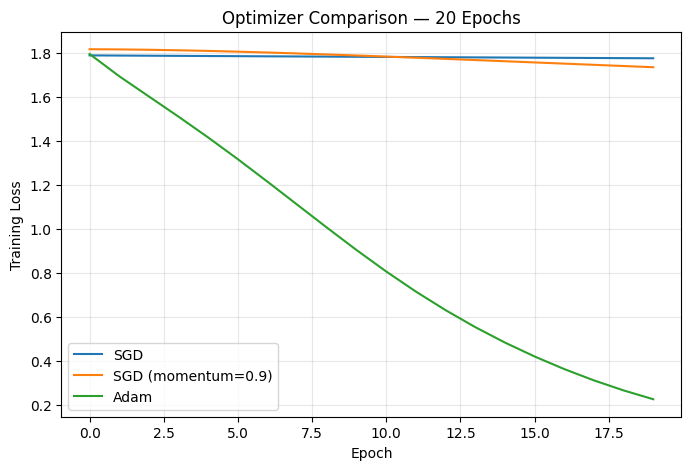

Final losses:
  SGD:              1.7765
  SGD + momentum:   1.7359
  Adam:             0.2262


In [6]:


def train_with_optimizer(optimizer_name, epochs=20, lr=0.01):
    model = SimpleNN(input_size=100, hidden_size=32, num_classes=6,
                      activation="relu").to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "sgd_momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

sgd_losses = train_with_optimizer("sgd")
sgd_mom_losses = train_with_optimizer("sgd_momentum")
adam_losses = train_with_optimizer("adam")

plt.figure(figsize=(8, 5))
plt.plot(sgd_losses, label="SGD")
plt.plot(sgd_mom_losses, label="SGD (momentum=0.9)")
plt.plot(adam_losses, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Optimizer Comparison — 20 Epochs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final losses:")
print(f"  SGD:              {sgd_losses[-1]:.4f}")
print(f"  SGD + momentum:   {sgd_mom_losses[-1]:.4f}")
print(f"  Adam:             {adam_losses[-1]:.4f}")

In [7]:

def count_params(model):
    return sum(p.numel() for p in model.parameters())

model_for_count = SimpleNN(input_size=100, hidden_size=32, num_classes=6).to(device)
n_params = count_params(model_for_count)
bytes_per_param = 4  # float32

print(f"Model parameters: {n_params}")
print(f"Parameter memory (weights only): {n_params * bytes_per_param / 1024:.2f} KB\n")

# SGD (no momentum): stores only the gradients alongside params -> 2x param memory
sgd_mem = n_params * bytes_per_param * 2

# SGD with momentum: stores params + gradients + 1 momentum buffer -> 3x param memory
sgd_mom_mem = n_params * bytes_per_param * 3

# Adam: stores params + gradients + 1st moment (m) + 2nd moment (v) -> 4x param memory
adam_mem = n_params * bytes_per_param * 4

print(f"Estimated optimizer memory (params + grads + optimizer state):")
print(f"  SGD:              {sgd_mem / 1024:.2f} KB")
print(f"  SGD + momentum:   {sgd_mom_mem / 1024:.2f} KB")
print(f"  Adam:             {adam_mem / 1024:.2f} KB")

Model parameters: 3430
Parameter memory (weights only): 13.40 KB

Estimated optimizer memory (params + grads + optimizer state):
  SGD:              26.80 KB
  SGD + momentum:   40.20 KB
  Adam:             53.59 KB


In [8]:


X_full, y_full = generate_synthetic_data(n_samples=800)

# 70/30 split
n_train = 560
X_train2, y_train2 = X_full[:n_train].to(device), y_full[:n_train].to(device)
X_val2, y_val2 = X_full[n_train:].to(device), y_full[n_train:].to(device)

print(f"Train size: {X_train2.shape[0]}, Val size: {X_val2.shape[0]}")

Train size: 560, Val size: 240


In [9]:
class SimpleNNVariant(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, variant="baseline"):
        super(SimpleNNVariant, self).__init__()
        self.variant = variant
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()

        if variant == "batchnorm":
            self.bn = nn.BatchNorm1d(hidden_size)
        elif variant == "dropout":
            self.drop = nn.Dropout(0.3)

        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.fc1(x)

        if self.variant == "batchnorm":
            x = self.bn(x)
            x = self.relu(x)
        elif self.variant == "dropout":
            x = self.relu(x)
            x = self.drop(x)
        else:
            x = self.relu(x)

        x = self.fc2(x)
        return x

def train_and_validate(variant, epochs=20, lr=0.01):
    model = SimpleNNVariant(input_size=100, hidden_size=32, num_classes=6,
                             variant=variant).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ---- Training step ----
        model.train()  # enables Dropout / BatchNorm's training-mode statistics
        optimizer.zero_grad()
        outputs = model(X_train2)
        loss = criterion(outputs, y_train2)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # ---- Validation step ----
        model.eval()  # disables Dropout, freezes BatchNorm running stats
        with torch.no_grad():
            val_outputs = model(X_val2)
            val_loss = criterion(val_outputs, y_val2)
            val_losses.append(val_loss.item())

    return train_losses, val_losses

baseline_train, baseline_val = train_and_validate("baseline")
bn_train, bn_val = train_and_validate("batchnorm")
dropout_train, dropout_val = train_and_validate("dropout")

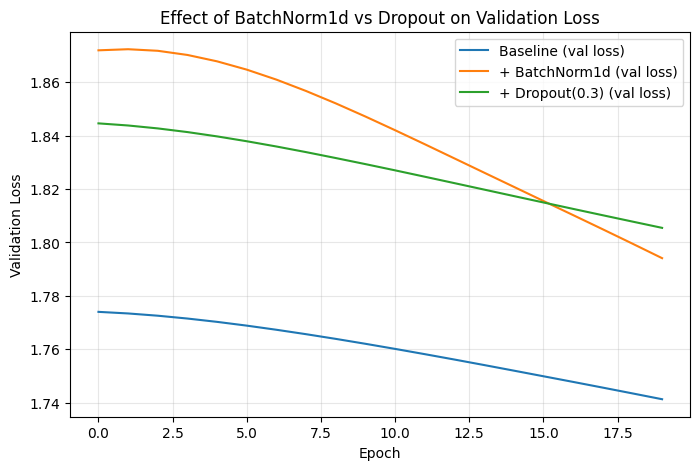

Final validation losses:
  Baseline:   1.7413
  BatchNorm:  1.7941
  Dropout:    1.8055


In [10]:
plt.figure(figsize=(8, 5))
plt.plot(baseline_val, label="Baseline (val loss)")
plt.plot(bn_val, label="+ BatchNorm1d (val loss)")
plt.plot(dropout_val, label="+ Dropout(0.3) (val loss)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Effect of BatchNorm1d vs Dropout on Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final validation losses:")
print(f"  Baseline:   {baseline_val[-1]:.4f}")
print(f"  BatchNorm:  {bn_val[-1]:.4f}")
print(f"  Dropout:    {dropout_val[-1]:.4f}")

# Part A: Defect Type Classifier

In [11]:
!pip install -q kaggle

from google.colab import files
print("Upload your kaggle.json file now:")
uploaded = files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d kaustubhdikshit/neu-surface-defect-database
!unzip -q neu-surface-defect-database.zip -d /content/neu_data
!ls /content/neu_data

Upload your kaggle.json file now:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database
License(s): unknown
100% 26.4M/26.4M [00:01<00:00, 22.3MB/s]

NEU-DET


In [12]:
import os

# Confirm images are directly inside class folders (not another nested level)
sample_class_dir = "/content/neu_data/NEU-DET/train/images/crazing"
print("Contents of crazing/ folder:", os.listdir(sample_class_dir)[:5])
print("Total files in crazing/:", len(os.listdir(sample_class_dir)))

Contents of crazing/ folder: ['crazing_193.jpg', 'crazing_215.jpg', 'crazing_141.jpg', 'crazing_152.jpg', 'crazing_45.jpg']
Total files in crazing/: 240


In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import Counter
from PIL import Image

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_root = "/content/neu_data/NEU-DET/train/images"
test_root  = "/content/neu_data/NEU-DET/validation/images"

Using device: cuda


In [14]:
basic_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
])

trainval_dataset = datasets.ImageFolder(root=train_root, transform=basic_transform)
test_dataset_raw = datasets.ImageFolder(root=test_root, transform=basic_transform)

print("Classes found:", trainval_dataset.classes)
assert trainval_dataset.classes == test_dataset_raw.classes, "Class mismatch between train and test folders!"

print(f"\nTrain+Val pool total: {len(trainval_dataset)}")
print(f"Test (held-out) total: {len(test_dataset_raw)}")

print("\nImages per class (train+val pool):")
class_counts = Counter(trainval_dataset.targets)
for idx, count in sorted(class_counts.items()):
    print(f"  {trainval_dataset.classes[idx]}: {count}")

print("\nImages per class (test/validation folder):")
test_counts = Counter(test_dataset_raw.targets)
for idx, count in sorted(test_counts.items()):
    print(f"  {test_dataset_raw.classes[idx]}: {count}")

sample_img, _ = trainval_dataset[0]
print(f"\nTensor shape after transform: {sample_img.shape}")

raw_path = trainval_dataset.samples[0][0]
raw_img = Image.open(raw_path)
print(f"Original file dimensions: {raw_img.size}, mode: {raw_img.mode}")

Classes found: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

Train+Val pool total: 1440
Test (held-out) total: 360

Images per class (train+val pool):
  crazing: 240
  inclusion: 240
  patches: 240
  pitted_surface: 240
  rolled-in_scale: 240
  scratches: 240

Images per class (test/validation folder):
  crazing: 60
  inclusion: 60
  patches: 60
  pitted_surface: 60
  rolled-in_scale: 60
  scratches: 60

Tensor shape after transform: torch.Size([1, 200, 200])
Original file dimensions: (200, 200), mode: RGB


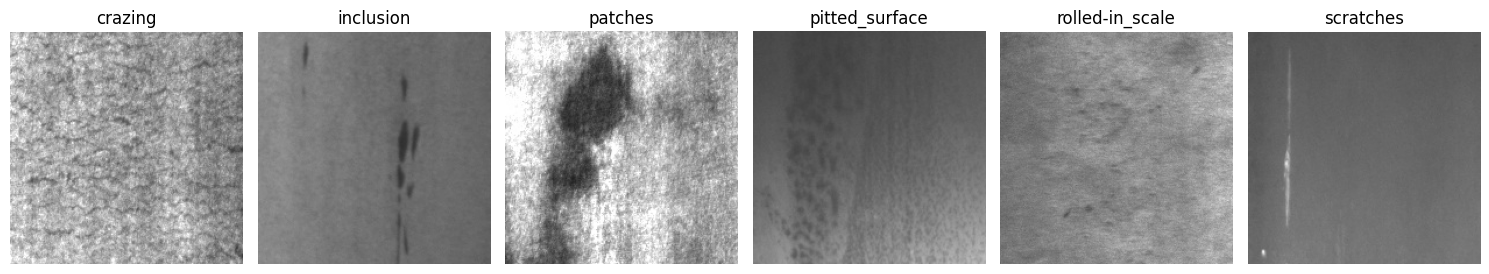

In [15]:
fig, axes = plt.subplots(1, len(trainval_dataset.classes), figsize=(15, 3))
seen_classes = {}
for img_path, label in trainval_dataset.samples:
    if label not in seen_classes:
        seen_classes[label] = img_path
    if len(seen_classes) == len(trainval_dataset.classes):
        break

for i, class_idx in enumerate(sorted(seen_classes.keys())):
    img = Image.open(seen_classes[class_idx])
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(trainval_dataset.classes[class_idx])
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [16]:
loader_for_stats = DataLoader(trainval_dataset, batch_size=64, shuffle=False)
mean_sum, std_sum, n_batches = 0.0, 0.0, 0
for images, _ in loader_for_stats:
    mean_sum += images.mean()
    std_sum += images.std()
    n_batches += 1

dataset_mean = (mean_sum / n_batches).item()
dataset_std = (std_sum / n_batches).item()
print(f"Computed mean: {dataset_mean:.4f}, std: {dataset_std:.4f}")

normalize_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[dataset_mean], std=[dataset_std]),
])

# Reload all three splits WITH normalization
trainval_norm = datasets.ImageFolder(root=train_root, transform=normalize_transform)
test_dataset  = datasets.ImageFolder(root=test_root, transform=normalize_transform)

# Split the train/ pool into 85% train / 15% val
# (test is already fully separate — the dataset's own validation/ folder)
n_total = len(trainval_norm)
n_train = int(0.85 * n_total)
n_val = n_total - n_train

train_ds, val_ds = random_split(
    trainval_norm, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

print(f"\nFinal split -> Train: {len(train_ds)}, Val: {len(val_ds)}, Test (held-out): {len(test_dataset)}")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Computed mean: 0.5032, std: 0.1663

Final split -> Train: 1224, Val: 216, Test (held-out): 360


In [17]:

class DefectCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(DefectCNN, self).__init__()

        # Block 1: 1 input channel (grayscale) -> 16 feature maps
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 200x200 -> 100x100

        # Block 2: 16 -> 32 feature maps
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 100x100 -> 50x50

        self.flatten = nn.Flatten()
        # After 2 pools: 200 -> 100 -> 50, so feature map is 32 channels x 50 x 50
        self.fc_out = nn.Linear(32 * 50 * 50, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.fc_out(x)  # raw logits
        return x

# Sanity check shape before full training
model_check = DefectCNN().to(device)
dummy = torch.randn(4, 1, 200, 200).to(device)
out = model_check(dummy)
print("Output shape:", out.shape)  # expect [4, 6]

total_params = sum(p.numel() for p in model_check.parameters())
print(f"Total trainable parameters: {total_params:,}")

Output shape: torch.Size([4, 6])
Total trainable parameters: 484,806


In [18]:
# ------------------------------------------------------------
# Task 4: Full training loop — 15 epochs
# ------------------------------------------------------------

def train_model(model, train_loader, val_loader, epochs=15, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validation ----
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return history

model_partA = DefectCNN().to(device)
history_partA = train_model(model_partA, train_loader, val_loader, epochs=15, lr=0.001)

Epoch 1/15 | Train Loss: 1.4586, Train Acc: 0.6005 | Val Loss: 0.5612, Val Acc: 0.8056
Epoch 2/15 | Train Loss: 0.4765, Train Acc: 0.8480 | Val Loss: 0.3174, Val Acc: 0.8889
Epoch 3/15 | Train Loss: 0.2728, Train Acc: 0.9126 | Val Loss: 0.4499, Val Acc: 0.8380
Epoch 4/15 | Train Loss: 0.2932, Train Acc: 0.9199 | Val Loss: 0.3206, Val Acc: 0.9167
Epoch 5/15 | Train Loss: 0.1757, Train Acc: 0.9534 | Val Loss: 0.2413, Val Acc: 0.9028
Epoch 6/15 | Train Loss: 0.1228, Train Acc: 0.9649 | Val Loss: 0.2612, Val Acc: 0.8843
Epoch 7/15 | Train Loss: 0.1112, Train Acc: 0.9681 | Val Loss: 0.2506, Val Acc: 0.9167
Epoch 8/15 | Train Loss: 0.1010, Train Acc: 0.9747 | Val Loss: 0.2392, Val Acc: 0.9120
Epoch 9/15 | Train Loss: 0.0643, Train Acc: 0.9845 | Val Loss: 0.2224, Val Acc: 0.9398
Epoch 10/15 | Train Loss: 0.0657, Train Acc: 0.9771 | Val Loss: 0.2004, Val Acc: 0.9306
Epoch 11/15 | Train Loss: 0.0642, Train Acc: 0.9845 | Val Loss: 0.2796, Val Acc: 0.8935
Epoch 12/15 | Train Loss: 0.0657, Train A

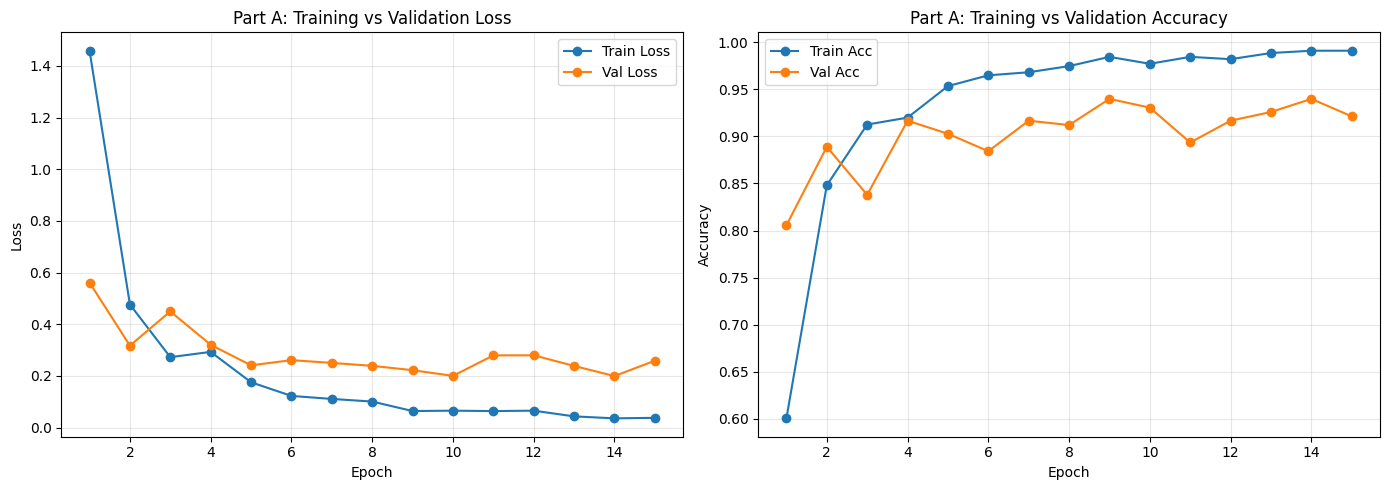

In [19]:
epochs_range = range(1, len(history_partA["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history_partA["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs_range, history_partA["val_loss"], label="Val Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Part A: Training vs Validation Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_partA["train_acc"], label="Train Acc", marker="o")
axes[1].plot(epochs_range, history_partA["val_acc"], label="Val Acc", marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Part A: Training vs Validation Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
def detect_overfitting_start(history):
    train_loss = history["train_loss"]
    val_loss = history["val_loss"]

    for i in range(2, len(val_loss)):
        train_decreasing = train_loss[i] < train_loss[i-1]
        val_increasing_twice = (val_loss[i] > val_loss[i-1]) and (val_loss[i-1] > val_loss[i-2])
        if train_decreasing and val_increasing_twice:
            return i + 1  # epoch number (1-indexed)
    return None

overfit_epoch = detect_overfitting_start(history_partA)
if overfit_epoch:
    print(f"Overfitting pattern detected starting around epoch {overfit_epoch}")
else:
    print("No clear sustained overfitting pattern detected across these 15 epochs.")

# Also print the raw gap between train and val loss at the final epoch —
# a large persistent gap is itself evidence of overfitting even without a rising val curve
final_gap = history_partA["train_loss"][-1] - history_partA["val_loss"][-1]
print(f"Train-Val loss gap at final epoch: {abs(final_gap):.4f}")
print(f"Final train acc: {history_partA['train_acc'][-1]:.4f}, Final val acc: {history_partA['val_acc'][-1]:.4f}")

No clear sustained overfitting pattern detected across these 15 epochs.
Train-Val loss gap at final epoch: 0.2211
Final train acc: 0.9910, Final val acc: 0.9213


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

model_partA.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_partA(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = test_dataset.classes

print("Classification report (test set):\n")
report = classification_report(all_labels, all_preds, target_names=class_names, digits=3)
print(report)

# Also get it as a dict so we can programmatically find the worst F1 class
report_dict = classification_report(all_labels, all_preds, target_names=class_names,
                                     output_dict=True)
f1_scores = {cls: report_dict[cls]["f1-score"] for cls in class_names}
worst_class = min(f1_scores, key=f1_scores.get)
print(f"\nLowest F1-score class: '{worst_class}' (F1 = {f1_scores[worst_class]:.3f})")

Classification report (test set):

                 precision    recall  f1-score   support

        crazing      0.864     0.850     0.857        60
      inclusion      0.920     0.767     0.836        60
        patches      0.788     0.867     0.825        60
 pitted_surface      0.850     0.850     0.850        60
rolled-in_scale      0.674     1.000     0.805        60
      scratches      0.778     0.467     0.583        60

       accuracy                          0.800       360
      macro avg      0.812     0.800     0.793       360
   weighted avg      0.812     0.800     0.793       360


Lowest F1-score class: 'scratches' (F1 = 0.583)


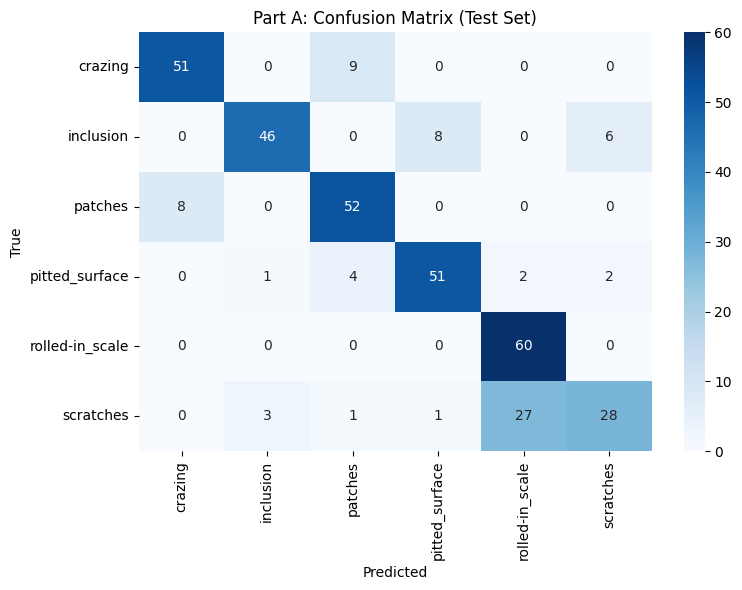

In [22]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Part A: Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

Found 17 crazing<->patches confusions out of 360 test images


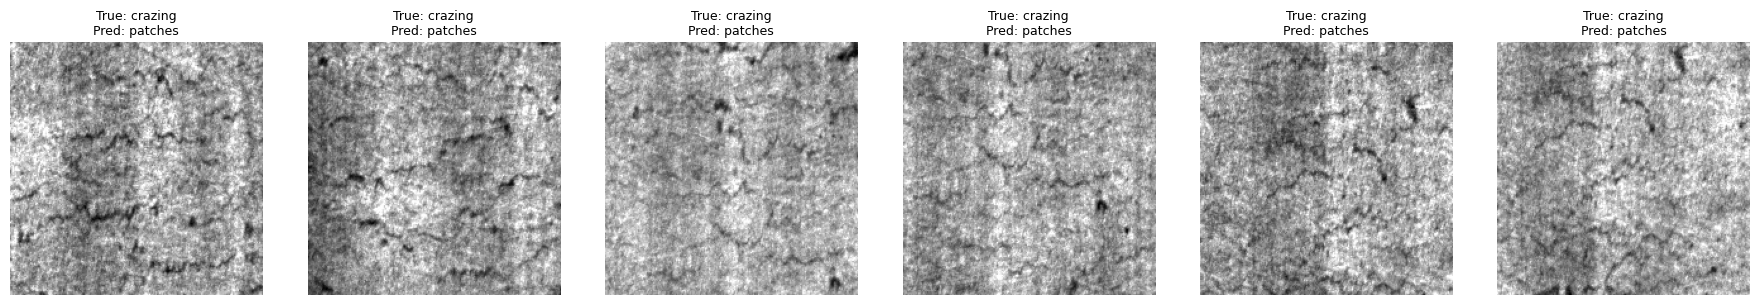

In [23]:
crazing_idx = class_names.index("crazing")
patches_idx = class_names.index("patches")

# Find test images where true=crazing but predicted=patches, or vice versa
confused_indices = []
for i, (true_l, pred_l) in enumerate(zip(all_labels, all_preds)):
    if (true_l == crazing_idx and pred_l == patches_idx) or \
       (true_l == patches_idx and pred_l == crazing_idx):
        confused_indices.append(i)

print(f"Found {len(confused_indices)} crazing<->patches confusions out of {len(all_labels)} test images")

# Visualize up to 6 of these misclassified examples
if len(confused_indices) > 0:
    n_show = min(6, len(confused_indices))
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
    if n_show == 1:
        axes = [axes]

    # Need to pull the actual image tensors back out of test_dataset by index
    # test_loader shuffled=False, so we can map back via the dataset directly
    shown = 0
    for batch_idx, (images, labels) in enumerate(test_loader):
        for j in range(images.size(0)):
            global_idx = batch_idx * test_loader.batch_size + j
            if global_idx in confused_indices[:n_show] and shown < n_show:
                img = images[j].squeeze().numpy()  # undo channel dim for grayscale display
                true_name = class_names[all_labels[global_idx]]
                pred_name = class_names[all_preds[global_idx]]
                axes[shown].imshow(img, cmap="gray")
                axes[shown].set_title(f"True: {true_name}\nPred: {pred_name}", fontsize=9)
                axes[shown].axis("off")
                shown += 1
        if shown >= n_show:
            break

    plt.tight_layout()
    plt.show()
else:
    print("No crazing/patches confusions found in this run — check other class pairs in the confusion matrix instead.")

# Part B — Model Hardening

In [24]:
train_augment_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((200, 200)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomCrop(180),          # crops down from 200x200 -> 180x180
    transforms.Resize((200, 200)),        # resize back up so batch shapes stay consistent
    transforms.ToTensor(),
    transforms.Normalize(mean=[dataset_mean], std=[dataset_std]),
])

# Validation and test transforms stay DETERMINISTIC — same as Part A, no augmentation
val_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[dataset_mean], std=[dataset_std]),
])

# Rebuild datasets: augmented version for train, clean version for val/test
trainval_augmented = datasets.ImageFolder(root=train_root, transform=train_augment_transform)
trainval_clean = datasets.ImageFolder(root=train_root, transform=val_test_transform)
test_dataset_clean = datasets.ImageFolder(root=test_root, transform=val_test_transform)

# Reuse the SAME split indices as Part A (same seed) so train/val split is identical —
# only the train transform differs. We do this by splitting indices once, then
# applying different underlying datasets with those indices via Subset.
from torch.utils.data import Subset

n_total = len(trainval_augmented)
n_train = int(0.85 * n_total)
n_val = n_total - n_train

generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(
    range(n_total), [n_train, n_val], generator=generator
)

train_ds_aug = Subset(trainval_augmented, train_indices.indices)   # augmented transform
val_ds_clean = Subset(trainval_clean, val_indices.indices)          # clean transform, no augmentation

train_loader_aug = DataLoader(train_ds_aug, batch_size=32, shuffle=True)
val_loader_clean = DataLoader(val_ds_clean, batch_size=32, shuffle=False)
test_loader_clean = DataLoader(test_dataset_clean, batch_size=32, shuffle=False)

print(f"Augmented train set: {len(train_ds_aug)}")
print(f"Clean val set: {len(val_ds_clean)}")
print(f"Clean test set: {len(test_dataset_clean)}")

Augmented train set: 1224
Clean val set: 216
Clean test set: 360


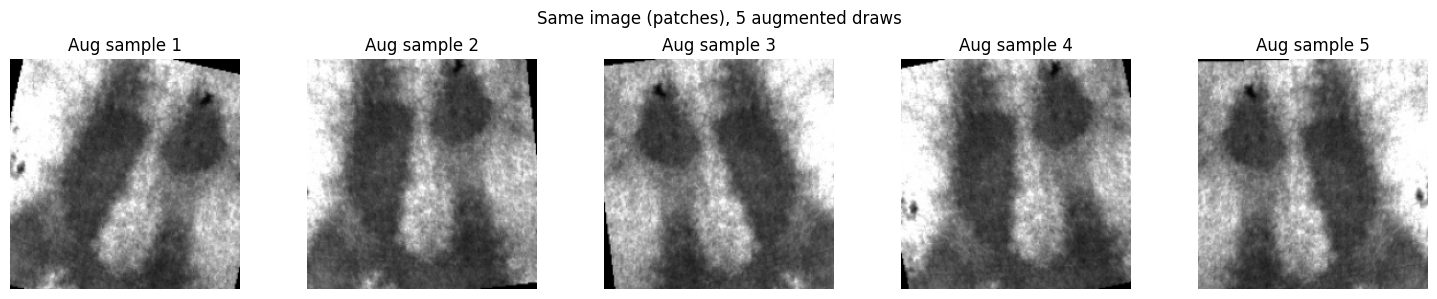

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
sample_idx = train_indices.indices[0]
for i in range(5):
    img, label = trainval_augmented[sample_idx]  # re-fetching re-applies random augmentation each time
    axes[i].imshow(img.squeeze().numpy(), cmap="gray")
    axes[i].set_title(f"Aug sample {i+1}")
    axes[i].axis("off")
plt.suptitle(f"Same image ({trainval_augmented.classes[label]}), 5 augmented draws")
plt.tight_layout()
plt.show()

In [26]:
class DefectCNNHardened(nn.Module):
    def __init__(self, num_classes=6, use_batchnorm=False, dropout_p=0.0):
        super(DefectCNNHardened, self).__init__()
        self.use_batchnorm = use_batchnorm

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16) if use_batchnorm else None
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32) if use_batchnorm else None
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(dropout_p) if dropout_p > 0 else None
        self.fc_out = nn.Linear(32 * 50 * 50, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        if self.bn1 is not None:
            x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        if self.bn2 is not None:
            x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)
        if self.dropout is not None:
            x = self.dropout(x)
        x = self.fc_out(x)
        return x

# Sanity check
test_model = DefectCNNHardened(use_batchnorm=True, dropout_p=0.4).to(device)
dummy = torch.randn(4, 1, 200, 200).to(device)
print("Output shape:", test_model(dummy).shape)

Output shape: torch.Size([4, 6])


In [27]:
def train_model_full(model, train_loader, val_loader, epochs=15, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return history

In [28]:
print("=== Training: Baseline architecture + Augmentation ===")
model_aug = DefectCNNHardened(use_batchnorm=False, dropout_p=0.0).to(device)
history_aug = train_model_full(model_aug, train_loader_aug, val_loader_clean, epochs=15, lr=0.001)

=== Training: Baseline architecture + Augmentation ===
Epoch 1/15 | Train Loss: 2.5498, Train Acc: 0.4232 | Val Loss: 1.2981, Val Acc: 0.5833
Epoch 2/15 | Train Loss: 1.0606, Train Acc: 0.6642 | Val Loss: 1.0480, Val Acc: 0.5556
Epoch 3/15 | Train Loss: 0.7492, Train Acc: 0.7541 | Val Loss: 0.7250, Val Acc: 0.7222
Epoch 4/15 | Train Loss: 0.5929, Train Acc: 0.8039 | Val Loss: 1.0322, Val Acc: 0.5509
Epoch 5/15 | Train Loss: 0.5293, Train Acc: 0.8235 | Val Loss: 0.5084, Val Acc: 0.7778
Epoch 6/15 | Train Loss: 0.4427, Train Acc: 0.8464 | Val Loss: 0.6023, Val Acc: 0.7824
Epoch 7/15 | Train Loss: 0.4043, Train Acc: 0.8668 | Val Loss: 0.5556, Val Acc: 0.7824
Epoch 8/15 | Train Loss: 0.3695, Train Acc: 0.8717 | Val Loss: 0.6231, Val Acc: 0.7778
Epoch 9/15 | Train Loss: 0.3473, Train Acc: 0.8807 | Val Loss: 0.4589, Val Acc: 0.8472
Epoch 10/15 | Train Loss: 0.3050, Train Acc: 0.8913 | Val Loss: 0.6133, Val Acc: 0.7870
Epoch 11/15 | Train Loss: 0.3034, Train Acc: 0.8995 | Val Loss: 0.6551, Va

In [29]:
print("=== Training: Augmentation + BatchNorm2d + Dropout(0.4) ===")
model_hardened = DefectCNNHardened(use_batchnorm=True, dropout_p=0.4).to(device)
history_hardened = train_model_full(model_hardened, train_loader_aug, val_loader_clean, epochs=15, lr=0.001)

=== Training: Augmentation + BatchNorm2d + Dropout(0.4) ===
Epoch 1/15 | Train Loss: 6.3801, Train Acc: 0.5596 | Val Loss: 4.5663, Val Acc: 0.5185
Epoch 2/15 | Train Loss: 3.0587, Train Acc: 0.6887 | Val Loss: 8.0244, Val Acc: 0.5463
Epoch 3/15 | Train Loss: 2.6118, Train Acc: 0.7435 | Val Loss: 5.7250, Val Acc: 0.6296
Epoch 4/15 | Train Loss: 2.2271, Train Acc: 0.7868 | Val Loss: 3.8317, Val Acc: 0.7315
Epoch 5/15 | Train Loss: 2.8935, Train Acc: 0.7541 | Val Loss: 6.9628, Val Acc: 0.6157
Epoch 6/15 | Train Loss: 1.8646, Train Acc: 0.7704 | Val Loss: 5.4973, Val Acc: 0.7037
Epoch 7/15 | Train Loss: 2.4398, Train Acc: 0.7753 | Val Loss: 11.5238, Val Acc: 0.6528
Epoch 8/15 | Train Loss: 2.9764, Train Acc: 0.7704 | Val Loss: 8.6595, Val Acc: 0.6435
Epoch 9/15 | Train Loss: 1.8500, Train Acc: 0.8186 | Val Loss: 5.9444, Val Acc: 0.7130
Epoch 10/15 | Train Loss: 1.6562, Train Acc: 0.8260 | Val Loss: 9.8392, Val Acc: 0.5880
Epoch 11/15 | Train Loss: 2.5231, Train Acc: 0.7982 | Val Loss: 7.50

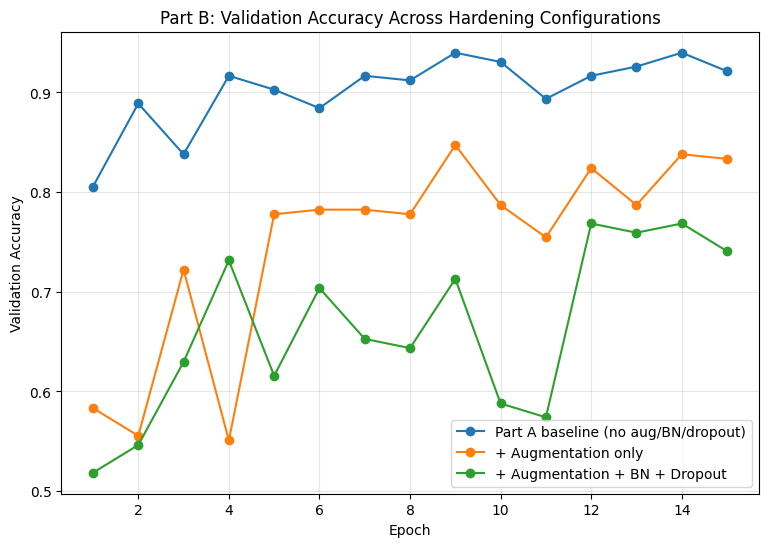

Final validation accuracy by config:
  Baseline:                    0.9213
  + Augmentation:              0.8333
  + Augmentation + BN + Drop:  0.7407


In [30]:
plt.figure(figsize=(9, 6))
plt.plot(range(1, 16), history_partA["val_acc"], label="Part A baseline (no aug/BN/dropout)", marker="o")
plt.plot(range(1, 16), history_aug["val_acc"], label="+ Augmentation only", marker="o")
plt.plot(range(1, 16), history_hardened["val_acc"], label="+ Augmentation + BN + Dropout", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Part B: Validation Accuracy Across Hardening Configurations")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final validation accuracy by config:")
print(f"  Baseline:                    {history_partA['val_acc'][-1]:.4f}")
print(f"  + Augmentation:              {history_aug['val_acc'][-1]:.4f}")
print(f"  + Augmentation + BN + Drop:  {history_hardened['val_acc'][-1]:.4f}")

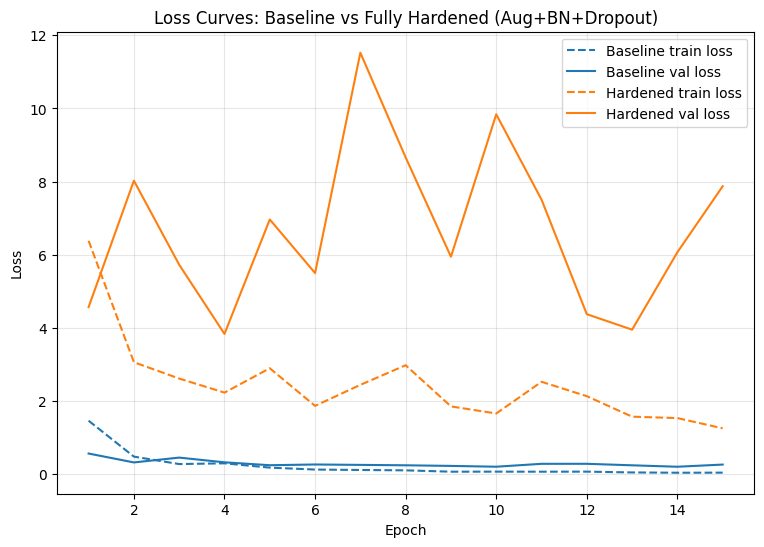

In [31]:
plt.figure(figsize=(9, 6))
plt.plot(range(1, 16), history_partA["train_loss"], label="Baseline train loss", linestyle="--", color="tab:blue")
plt.plot(range(1, 16), history_partA["val_loss"], label="Baseline val loss", color="tab:blue")
plt.plot(range(1, 16), history_hardened["train_loss"], label="Hardened train loss", linestyle="--", color="tab:orange")
plt.plot(range(1, 16), history_hardened["val_loss"], label="Hardened val loss", color="tab:orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves: Baseline vs Fully Hardened (Aug+BN+Dropout)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Part C: Hyperparameter Tuning

In [32]:
import itertools
import time
import pandas as pd

def train_model_track_time(model, train_loader, val_loader, epochs=15, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return history

# Grid search config — using PLAIN baseline architecture (winner of Part B)
learning_rates = [0.001, 0.01]
batch_sizes = [16, 32]

grid_results = []

for lr, bs in itertools.product(learning_rates, batch_sizes):
    print(f"\n=== Training: lr={lr}, batch_size={bs} (baseline architecture) ===")

    train_loader_grid = DataLoader(train_ds, batch_size=bs, shuffle=True)  # Part A's clean, non-augmented train_ds
    val_loader_grid = DataLoader(val_ds, batch_size=bs, shuffle=False)

    torch.manual_seed(42)
    model_grid = DefectCNN().to(device)  # plain baseline architecture from Part A

    start_time = time.time()
    hist = train_model_track_time(model_grid, train_loader_grid, val_loader_grid, epochs=15, lr=lr)
    elapsed = time.time() - start_time

    final_val_acc = hist["val_acc"][-1]
    best_val_acc = max(hist["val_acc"])

    grid_results.append({
        "lr": lr, "batch_size": bs,
        "final_val_acc": final_val_acc, "best_val_acc": best_val_acc,
        "train_time_sec": elapsed, "history": hist
    })

    print(f"Final val acc: {final_val_acc:.4f} | Best val acc: {best_val_acc:.4f} | Time: {elapsed:.1f}s")


=== Training: lr=0.001, batch_size=16 (baseline architecture) ===
Final val acc: 0.9028 | Best val acc: 0.9259 | Time: 37.1s

=== Training: lr=0.001, batch_size=32 (baseline architecture) ===
Final val acc: 0.9259 | Best val acc: 0.9259 | Time: 35.9s

=== Training: lr=0.01, batch_size=16 (baseline architecture) ===
Final val acc: 0.1250 | Best val acc: 0.1852 | Time: 36.6s

=== Training: lr=0.01, batch_size=32 (baseline architecture) ===
Final val acc: 0.1250 | Best val acc: 0.1852 | Time: 36.5s


In [34]:
# Create results DataFrame
results_df = pd.DataFrame([
    {
        "Learning Rate": r["lr"],
        "Batch Size": r["batch_size"],
        "Final Val Acc": round(r["final_val_acc"], 4),
        "Best Val Acc": round(r["best_val_acc"], 4),
        "Train Time (s)": round(r["train_time_sec"], 1),
    }
    for r in grid_results
])

# Sort by best validation accuracy
results_df = results_df.sort_values(
    "Best Val Acc", ascending=False
).reset_index(drop=True)

print(results_df.to_string(index=False))

# Get best configuration from original results (avoid float comparison)
best_config = max(grid_results, key=lambda x: x["best_val_acc"])

print(
    f"\nBest config: lr={best_config['lr']}, "
    f"batch_size={best_config['batch_size']}, "
    f"best_val_acc={best_config['best_val_acc']:.4f}"
)

 Learning Rate  Batch Size  Final Val Acc  Best Val Acc  Train Time (s)
         0.001          16         0.9028        0.9259            37.1
         0.001          32         0.9259        0.9259            35.9
         0.010          16         0.1250        0.1852            36.6
         0.010          32         0.1250        0.1852            36.5

Best config: lr=0.001, batch_size=16, best_val_acc=0.9259


In [35]:
df_impact = pd.DataFrame(grid_results)
lr_effect = df_impact.groupby("lr")["best_val_acc"].mean()
bs_effect = df_impact.groupby("batch_size")["best_val_acc"].mean()

print("Avg best val acc by learning rate:\n", lr_effect)
print("\nAvg best val acc by batch size:\n", bs_effect)

lr_range = lr_effect.max() - lr_effect.min()
bs_range = bs_effect.max() - bs_effect.min()
print(f"\nSpread from LR: {lr_range:.4f} | Spread from batch size: {bs_range:.4f}")
print(f"-> {'Learning rate' if lr_range > bs_range else 'Batch size'} had more impact")

Avg best val acc by learning rate:
 lr
0.001    0.925926
0.010    0.185185
Name: best_val_acc, dtype: float64

Avg best val acc by batch size:
 batch_size
16    0.555556
32    0.555556
Name: best_val_acc, dtype: float64

Spread from LR: 0.7407 | Spread from batch size: 0.0000
-> Learning rate had more impact


In [36]:
def train_with_scheduler(model, train_loader, val_loader, test_loader,
                          epochs=15, lr=0.001, step_size=5, gamma=0.5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss, val_acc = val_running_loss / val_total, val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        print(f"Epoch {epoch+1}/{epochs} | LR: {optimizer.param_groups[0]['lr']:.6f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        scheduler.step()

    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)
    test_acc = test_correct / test_total
    return history, test_acc

train_loader_best = DataLoader(train_ds, batch_size=best_config["batch_size"], shuffle=True)
val_loader_best = DataLoader(val_ds, batch_size=best_config["batch_size"], shuffle=False)

# Without scheduler (step_size huge -> never fires) for fair baseline comparison
torch.manual_seed(42)
model_no_sched = DefectCNN().to(device)
_, test_acc_no_sched = train_with_scheduler(
    model_no_sched, train_loader_best, val_loader_best, test_loader,
    epochs=15, lr=best_config["lr"], step_size=999, gamma=1.0
)
print(f"\n>>> Test accuracy WITHOUT scheduler: {test_acc_no_sched:.4f}")


Epoch 1/15 | LR: 0.001000 | Val Loss: 0.5596 | Val Acc: 0.8194
Epoch 2/15 | LR: 0.001000 | Val Loss: 0.3979 | Val Acc: 0.8611
Epoch 3/15 | LR: 0.001000 | Val Loss: 0.3593 | Val Acc: 0.8704
Epoch 4/15 | LR: 0.001000 | Val Loss: 0.3135 | Val Acc: 0.9120
Epoch 5/15 | LR: 0.001000 | Val Loss: 0.4456 | Val Acc: 0.8102
Epoch 6/15 | LR: 0.001000 | Val Loss: 0.3902 | Val Acc: 0.8426
Epoch 7/15 | LR: 0.001000 | Val Loss: 0.3150 | Val Acc: 0.9028
Epoch 8/15 | LR: 0.001000 | Val Loss: 0.2692 | Val Acc: 0.9213
Epoch 9/15 | LR: 0.001000 | Val Loss: 0.3029 | Val Acc: 0.8981
Epoch 10/15 | LR: 0.001000 | Val Loss: 0.3269 | Val Acc: 0.8796
Epoch 11/15 | LR: 0.001000 | Val Loss: 0.4070 | Val Acc: 0.8750
Epoch 12/15 | LR: 0.001000 | Val Loss: 0.5604 | Val Acc: 0.8241
Epoch 13/15 | LR: 0.001000 | Val Loss: 0.5149 | Val Acc: 0.8287
Epoch 14/15 | LR: 0.001000 | Val Loss: 0.5239 | Val Acc: 0.8657
Epoch 15/15 | LR: 0.001000 | Val Loss: 0.4474 | Val Acc: 0.8750

>>> Test accuracy WITHOUT scheduler: 0.8056


In [37]:
# With actual StepLR schedule
torch.manual_seed(42)
model_with_sched = DefectCNN().to(device)
history_sched, test_acc_with_sched = train_with_scheduler(
    model_with_sched, train_loader_best, val_loader_best, test_loader,
    epochs=15, lr=best_config["lr"], step_size=5, gamma=0.5
)

print(f"\n>>> Test accuracy WITH StepLR:    {test_acc_with_sched:.4f}")
print(f">>> Test accuracy WITHOUT StepLR: {test_acc_no_sched:.4f}")
print(f">>> Difference: {test_acc_with_sched - test_acc_no_sched:+.4f}")

Epoch 1/15 | LR: 0.001000 | Val Loss: 0.5595 | Val Acc: 0.8194
Epoch 2/15 | LR: 0.001000 | Val Loss: 0.4034 | Val Acc: 0.8611
Epoch 3/15 | LR: 0.001000 | Val Loss: 0.3529 | Val Acc: 0.8704
Epoch 4/15 | LR: 0.001000 | Val Loss: 0.4053 | Val Acc: 0.8704
Epoch 5/15 | LR: 0.001000 | Val Loss: 0.3314 | Val Acc: 0.8843
Epoch 6/15 | LR: 0.000500 | Val Loss: 0.2954 | Val Acc: 0.8796
Epoch 7/15 | LR: 0.000500 | Val Loss: 0.3290 | Val Acc: 0.9074
Epoch 8/15 | LR: 0.000500 | Val Loss: 0.2223 | Val Acc: 0.9398
Epoch 9/15 | LR: 0.000500 | Val Loss: 0.2469 | Val Acc: 0.9352
Epoch 10/15 | LR: 0.000500 | Val Loss: 0.2885 | Val Acc: 0.8981
Epoch 11/15 | LR: 0.000250 | Val Loss: 0.2402 | Val Acc: 0.9352
Epoch 12/15 | LR: 0.000250 | Val Loss: 0.2315 | Val Acc: 0.9259
Epoch 13/15 | LR: 0.000250 | Val Loss: 0.2827 | Val Acc: 0.9028
Epoch 14/15 | LR: 0.000250 | Val Loss: 0.2602 | Val Acc: 0.9259
Epoch 15/15 | LR: 0.000250 | Val Loss: 0.2483 | Val Acc: 0.9398

>>> Test accuracy WITH StepLR:    0.8972
>>> Tes

In [38]:
!pip install -q optuna
import optuna

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_int("batch_size", 8, 64, log=True)

    torch.manual_seed(42)
    train_loader_opt = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader_opt = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model_opt = DefectCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_opt.parameters(), lr=lr)

    epochs = 8
    best_val_acc = 0.0
    for epoch in range(epochs):
        model_opt.train()
        for images, labels in train_loader_opt:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model_opt(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model_opt.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader_opt:
                images, labels = images.to(device), labels.to(device)
                outputs = model_opt(images)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total
        best_val_acc = max(best_val_acc, val_acc)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_acc

study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=15)

print("\nBest trial:")
print(f"  Value (val acc): {study.best_trial.value:.4f}")
print(f"  Params: {study.best_trial.params}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 26.2 MB/s eta 0:00:00


[I 2026-07-08 16:50:22,268] A new study created in memory with name: no-name-c3b9efe3-e7f4-47ab-9cf6-bbd50ed8cf59
[I 2026-07-08 16:50:35,270] Trial 0 finished with value: 0.7546296296296297 and parameters: {'lr': 0.002894454623847897, 'batch_size': 62}. Best is trial 0 with value: 0.7546296296296297.
[I 2026-07-08 16:50:48,670] Trial 1 finished with value: 0.9212962962962963 and parameters: {'lr': 0.0005217615391712792, 'batch_size': 29}. Best is trial 1 with value: 0.9212962962962963.
[I 2026-07-08 16:51:05,203] Trial 2 finished with value: 0.19907407407407407 and parameters: {'lr': 0.02917934566096494, 'batch_size': 11}. Best is trial 1 with value: 0.9212962962962963.
[I 2026-07-08 16:51:19,126] Trial 3 finished with value: 0.1574074074074074 and parameters: {'lr': 0.01649937806938748, 'batch_size': 15}. Best is trial 1 with value: 0.9212962962962963.
[I 2026-07-08 16:51:32,572] Trial 4 finished with value: 0.19907407407407407 and parameters: {'lr': 0.0929404581364794, 'batch_size': 


Best trial:
  Value (val acc): 0.9213
  Params: {'lr': 0.0005217615391712792, 'batch_size': 29}


In [39]:
print("=== Grid Search vs Optuna ===")
print(f"Grid search best: lr={best_config['lr']}, batch_size={best_config['batch_size']}, "
      f"val_acc={best_config['best_val_acc']:.4f}")
print(f"Optuna best:      lr={study.best_trial.params['lr']:.5f}, "
      f"batch_size={study.best_trial.params['batch_size']}, "
      f"val_acc={study.best_trial.value:.4f}")

diff = study.best_trial.value - best_config["best_val_acc"]
print(f"\nOptuna vs grid search difference: {diff:+.4f}")

=== Grid Search vs Optuna ===
Grid search best: lr=0.001, batch_size=16, val_acc=0.9259
Optuna best:      lr=0.00052, batch_size=29, val_acc=0.9213

Optuna vs grid search difference: -0.0046
